## Q3.Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Load Dataset

df = pd.read_csv('q3_retail_promotions.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Date Feature Engineering

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
print(df.head())


  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

## Train - Test

In [3]:
# Train-Test Split

df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(columns=['items_sold', 'transaction_date'])
y_train = train['items_sold']

X_test = test.drop(columns=['items_sold', 'transaction_date'])
y_test = test['items_sold']

## Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Preprocessing Pipeline

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)


## Linnear Regression 

In [6]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)


Linear Regression RMSE: 27.121451164890622
Linear Regression MAE: 21.052926674588388


## Random Forest

In [7]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

In [8]:
# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Linear Regression RMSE: 27.121451164890622
Linear Regression MAE: 21.052926674588388

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


## Feature Importance

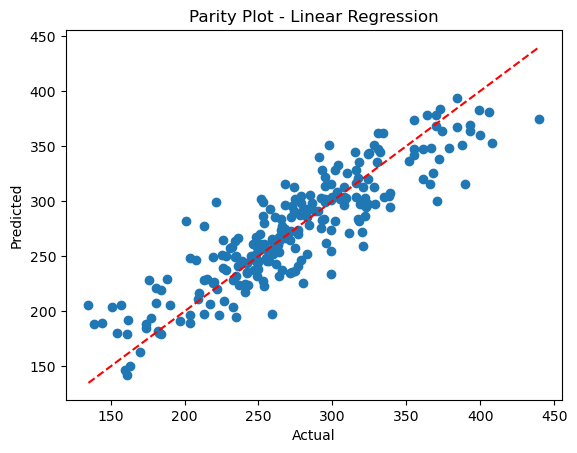

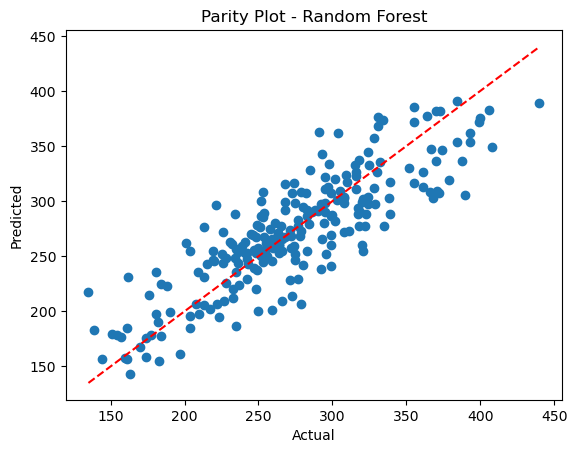

In [9]:
# Linear Regression
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot - Linear Regression")
plt.show()

# Random Forest
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot - Random Forest")
plt.show()

In [10]:
# Feature Importance

feature_names = pipeline_rf.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
13,num__is_festival,0.173473
10,cat__store_size_small,0.167683
7,cat__location_type_urban,0.108378
17,num__day_of_week,0.086316
12,num__is_weekend,0.061208
11,num__store_id,0.054882
5,cat__location_type_rural,0.053794
8,cat__store_size_large,0.051113
14,num__competition_density,0.050805
16,num__month,0.037383


In [11]:
print("\nFinal Conclusion:")
print("Random Forest performs better than Linear Regression due to its ability to capture non-linear patterns.")
print("The model evaluation using RMSE and MAE confirms this improvement.")


Final Conclusion:
Random Forest performs better than Linear Regression due to its ability to capture non-linear patterns.
The model evaluation using RMSE and MAE confirms this improvement.
